In [1]:
# By Joe Ho

In [2]:
# pip install tensorflow

In [3]:
# pip install PIL matplotlib

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [5]:
import pathlib

data_dir = pathlib.Path("./train")
data_dir

WindowsPath('train')

In [6]:
print(data_dir)
print(list(data_dir.glob('*/*.jpg')))


train
[WindowsPath('train/air hockey/001.jpg'), WindowsPath('train/air hockey/002.jpg'), WindowsPath('train/air hockey/003.jpg'), WindowsPath('train/air hockey/004.jpg'), WindowsPath('train/air hockey/005.jpg'), WindowsPath('train/air hockey/006.jpg'), WindowsPath('train/air hockey/007.jpg'), WindowsPath('train/air hockey/008.jpg'), WindowsPath('train/air hockey/009.jpg'), WindowsPath('train/air hockey/010.jpg'), WindowsPath('train/air hockey/011.jpg'), WindowsPath('train/air hockey/012.jpg'), WindowsPath('train/air hockey/013.jpg'), WindowsPath('train/air hockey/014.jpg'), WindowsPath('train/air hockey/015.jpg'), WindowsPath('train/air hockey/016.jpg'), WindowsPath('train/air hockey/017.jpg'), WindowsPath('train/air hockey/018.jpg'), WindowsPath('train/air hockey/019.jpg'), WindowsPath('train/air hockey/020.jpg'), WindowsPath('train/air hockey/021.jpg'), WindowsPath('train/air hockey/022.jpg'), WindowsPath('train/air hockey/023.jpg'), WindowsPath('train/air hockey/024.jpg'), WindowsPa

In [7]:
test_dir = pathlib.Path("./test")
test_dir

WindowsPath('test')

In [8]:
print(test_dir)
print(list(test_dir.glob('*/*.jpg')))

test
[WindowsPath('test/air hockey/1.jpg'), WindowsPath('test/air hockey/2.jpg'), WindowsPath('test/air hockey/3.jpg'), WindowsPath('test/air hockey/4.jpg'), WindowsPath('test/air hockey/5.jpg'), WindowsPath('test/ampute football/1.jpg'), WindowsPath('test/ampute football/2.jpg'), WindowsPath('test/ampute football/3.jpg'), WindowsPath('test/ampute football/4.jpg'), WindowsPath('test/ampute football/5.jpg'), WindowsPath('test/archery/1.jpg'), WindowsPath('test/archery/2.jpg'), WindowsPath('test/archery/3.jpg'), WindowsPath('test/archery/4.jpg'), WindowsPath('test/archery/5.jpg'), WindowsPath('test/arm wrestling/1.jpg'), WindowsPath('test/arm wrestling/2.jpg'), WindowsPath('test/arm wrestling/3.jpg'), WindowsPath('test/arm wrestling/4.jpg'), WindowsPath('test/arm wrestling/5.jpg'), WindowsPath('test/axe throwing/1.jpg'), WindowsPath('test/axe throwing/2.jpg'), WindowsPath('test/axe throwing/3.jpg'), WindowsPath('test/axe throwing/4.jpg'), WindowsPath('test/axe throwing/5.jpg'), WindowsPa

In [9]:
validate_dir = pathlib.Path("./valid")
validate_dir

WindowsPath('valid')

In [10]:
print(validate_dir)
print(list(validate_dir.glob('*/*.jpg')))

valid
[WindowsPath('valid/air hockey/1.jpg'), WindowsPath('valid/air hockey/2.jpg'), WindowsPath('valid/air hockey/3.jpg'), WindowsPath('valid/air hockey/4.jpg'), WindowsPath('valid/air hockey/5.jpg'), WindowsPath('valid/ampute football/1.jpg'), WindowsPath('valid/ampute football/2.jpg'), WindowsPath('valid/ampute football/3.jpg'), WindowsPath('valid/ampute football/4.jpg'), WindowsPath('valid/ampute football/5.jpg'), WindowsPath('valid/archery/1.jpg'), WindowsPath('valid/archery/2.jpg'), WindowsPath('valid/archery/3.jpg'), WindowsPath('valid/archery/4.jpg'), WindowsPath('valid/archery/5.jpg'), WindowsPath('valid/arm wrestling/1.jpg'), WindowsPath('valid/arm wrestling/2.jpg'), WindowsPath('valid/arm wrestling/3.jpg'), WindowsPath('valid/arm wrestling/4.jpg'), WindowsPath('valid/arm wrestling/5.jpg'), WindowsPath('valid/axe throwing/1.jpg'), WindowsPath('valid/axe throwing/2.jpg'), WindowsPath('valid/axe throwing/3.jpg'), WindowsPath('valid/axe throwing/4.jpg'), WindowsPath('valid/axe t

In [11]:
#Print Number of Training Data
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)


13572


In [12]:
pic1 = list(data_dir.glob('*/*.jpg'))
print(pic1[0])


train\air hockey\001.jpg


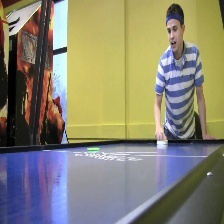

In [13]:
PIL.Image.open(str(pic1[0]))


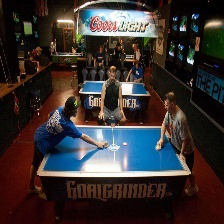

In [14]:
PIL.Image.open(str(pic1[1]))


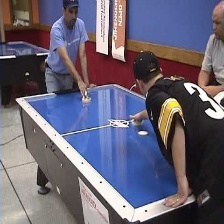

In [15]:
pic2 = list(data_dir.glob('../test/*/*.jpg'))
PIL.Image.open(str(pic2[0]))


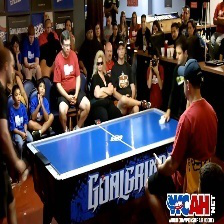

In [16]:
PIL.Image.open(str(pic2[1]))


In [17]:
batch_size = 32


In [18]:
import cv2

im = cv2.imread(str(pic1[0]))

img_height = im.shape[0]
img_width = im.shape[1]

print("Image Height: " + str(img_height))
print("Image Width: " + str(img_width))

Image Height: 224
Image Width: 224


In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 13572 files belonging to 100 classes.


In [20]:
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 500 files belonging to 100 classes.


In [21]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  validate_dir,  
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 500 files belonging to 100 classes.


In [22]:
class_names = train_ds.class_names
print(class_names)


['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading', 'chuckwagon racing', 'cricket', 'croquet', 'curling', 'disc golf', 'fencing', 'field hockey', 'figure skating men', 'figure skating pairs', 'figure skating women', 'fly fishing', 'football', 'formula 1 racing', 'frisbee', 'gaga', 'giant slalom', 'golf', 'hammer throw', 'hang gliding', 'harness racing', 'high jump', 'hockey', 'horse jumping', 'horse racing', 'horseshoe pitching', 'hurdles', 'hydroplane racing', 'ice climbing', 'ice yachting', 'jai alai', 'javelin', 'jousting', 'judo', 'lacrosse', 'log rolling', 'luge', 'motorcycle racing', 'mushing', 'nascar racing', 'olympic wrestling', 'parallel bar', 'pole climbing', 'pole dancing', 'pole vault', 'polo', 'pommel horse', 'rings', 'rock climbing', 'roller 

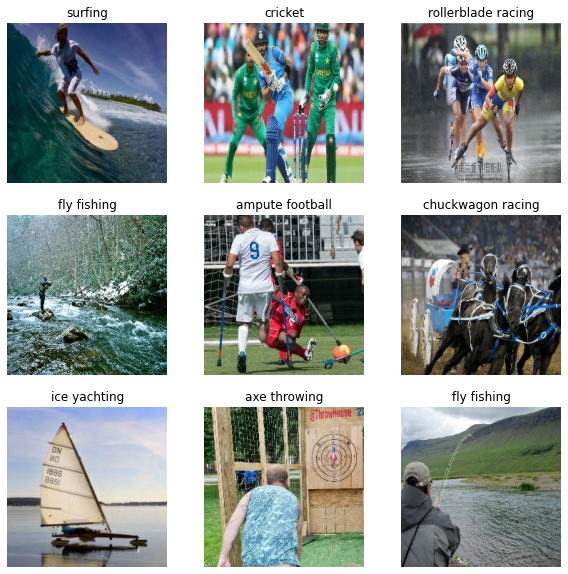

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")


In [24]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break


(32, 224, 224, 3)
(32,)


In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [26]:
normalization_layer = layers.Rescaling(1./255)


In [27]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [28]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(filters=16, kernel_size=3, strides=(1, 1), padding='valid', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Conv2D(filters=32, kernel_size=3, strides=(1, 1), padding='valid', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Conv2D(filters=64, kernel_size=3, strides=(1, 1),  padding='valid', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Conv2D(filters=128, kernel_size=3, strides=(1, 1),  padding='valid', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(units=192, activation='LeakyReLU'),
  layers.Dense(num_classes)
])


In [29]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [30]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 64)        1

In [31]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=test_ds,
  epochs=epochs
)


Epoch 1/10
425/425 [==============================] - 244s 572ms/step - loss: 3.4687 - accuracy: 0.1846 - val_loss: 2.4437 - val_accuracy: 0.3780
Epoch 2/10
425/425 [==============================] - 239s 562ms/step - loss: 2.1662 - accuracy: 0.4484 - val_loss: 1.9083 - val_accuracy: 0.4800
Epoch 3/10
425/425 [==============================] - 238s 559ms/step - loss: 1.1943 - accuracy: 0.6784 - val_loss: 1.9918 - val_accuracy: 0.5120
Epoch 4/10
425/425 [==============================] - 238s 561ms/step - loss: 0.4063 - accuracy: 0.8832 - val_loss: 2.8495 - val_accuracy: 0.4680
Epoch 5/10
425/425 [==============================] - 239s 563ms/step - loss: 0.2101 - accuracy: 0.9394 - val_loss: 3.2943 - val_accuracy: 0.4740
Epoch 6/10
425/425 [==============================] - 239s 562ms/step - loss: 0.1385 - accuracy: 0.9598 - val_loss: 3.6738 - val_accuracy: 0.4440
Epoch 7/10
425/425 [==============================] - 238s 561ms/step - loss: 0.1487 - accuracy: 0.9566 - val_loss: 4.1731 -

In [32]:
# evaluate the model against test data in the learning model
scores = model.evaluate(test_ds, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


accuracy: 41.80%


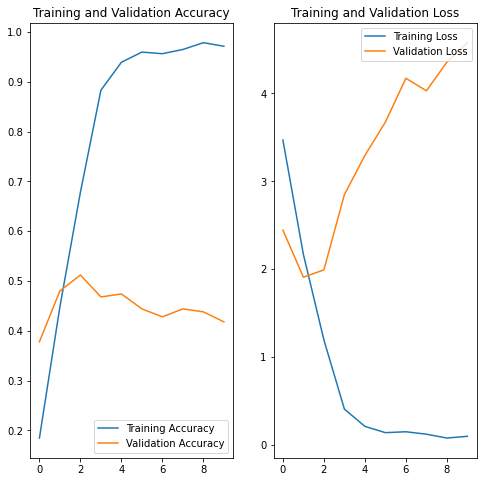

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [34]:
# evaluate the model against another set of validation data in the learning model
scores = model.evaluate(val_ds, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

accuracy: 41.20%


In [35]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)


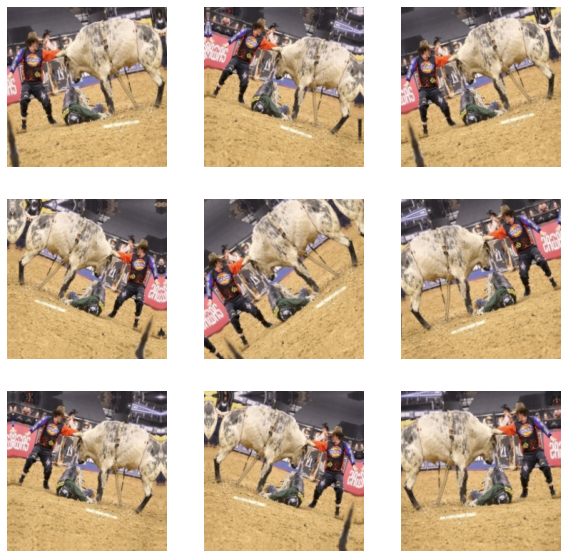

In [36]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")


In [37]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(filters=16, kernel_size=3, strides=(1, 1), padding='same', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Conv2D(filters=32, kernel_size=3, strides=(1, 1), padding='same', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Conv2D(filters=64, kernel_size=3, strides=(1, 1),  padding='same', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Conv2D(filters=128, kernel_size=3, strides=(1, 1),  padding='same', activation='LeakyReLU'),
  layers.MaxPooling2D(),
  layers.Dropout(rate=0.2),
  layers.Flatten(),
  layers.Dense(units=192, activation='LeakyReLU'),
  layers.Dense(num_classes)
])


In [38]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [39]:
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 224, 224, 16)      448       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 112, 112, 16)     0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 56, 56, 32)       0         
 2D)                                                  

In [40]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=test_ds,
  epochs=epochs
)


Epoch 1/15
425/425 [==============================] - 298s 699ms/step - loss: 3.6162 - accuracy: 0.1502 - val_loss: 2.9849 - val_accuracy: 0.2660
Epoch 2/15
425/425 [==============================] - 294s 693ms/step - loss: 2.6873 - accuracy: 0.3256 - val_loss: 2.2315 - val_accuracy: 0.4280
Epoch 3/15
425/425 [==============================] - 297s 699ms/step - loss: 2.2871 - accuracy: 0.4133 - val_loss: 2.4149 - val_accuracy: 0.4260
Epoch 4/15
425/425 [==============================] - 293s 690ms/step - loss: 2.0359 - accuracy: 0.4638 - val_loss: 2.3652 - val_accuracy: 0.4680
Epoch 5/15
425/425 [==============================] - 294s 691ms/step - loss: 1.8104 - accuracy: 0.5124 - val_loss: 2.1079 - val_accuracy: 0.5040
Epoch 6/15
425/425 [==============================] - 292s 688ms/step - loss: 1.6271 - accuracy: 0.5625 - val_loss: 2.1175 - val_accuracy: 0.5180
Epoch 7/15
425/425 [==============================] - 292s 687ms/step - loss: 1.5122 - accuracy: 0.5906 - val_loss: 2.3155 -

In [41]:
# evaluate the model against test data in the learning model
scores = model.evaluate(test_ds, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


accuracy: 58.80%


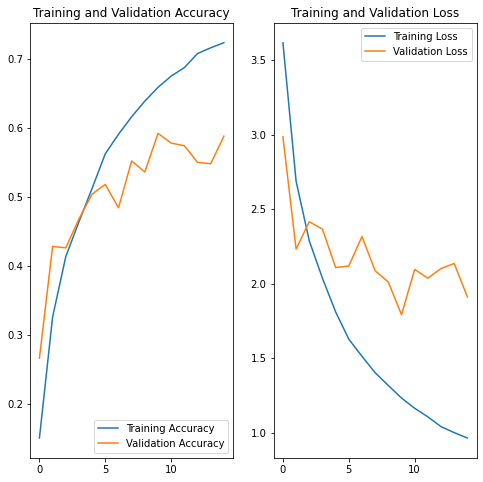

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [43]:
# evaluate the model against another set of validation data 
scores = model.evaluate(val_ds, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))



accuracy: 58.40%


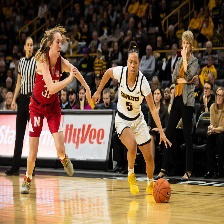

In [44]:
image_to_predict_1 = "./images to predict/2.jpg"
PIL.Image.open(image_to_predict_1)

In [45]:
test_valid_img_path = pathlib.Path(image_to_predict_1)

img = tf.keras.utils.load_img(
    test_valid_img_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)


This image most likely belongs to wheelchair basketball with a 56.64 percent confidence.


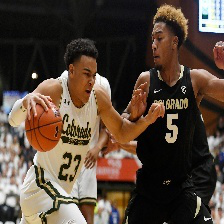

In [46]:
image_to_predict_2 = "./images to predict/5.jpg"
PIL.Image.open(image_to_predict_2)

In [47]:
test_valid_img_path = pathlib.Path(image_to_predict_2)

img = tf.keras.utils.load_img(
    test_valid_img_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)


This image most likely belongs to basketball with a 97.13 percent confidence.


In [48]:
#Save the Model
model_save_loc="./Joe_Train_Imaged_Model_CNN.h5"
model.save(model_save_loc)
print ('model was saved as ' , model_save_loc ) 

model was saved as  ./Joe_Train_Imaged_Model_CNN.h5
